In [4]:
import keras_tuner as kt

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler, OneHotEncoder, OrdinalEncoder

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

2024-03-22 13:27:19.392504: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-22 13:27:19.637236: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-22 13:27:19.637345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-22 13:27:19.660631: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-22 13:27:19.744250: I tensorflow/core/platform/cpu_feature_guar

In [5]:
tf.config.experimental.list_physical_devices()

2024-03-22 13:27:26.472408: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 13:27:27.154140: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 13:27:27.154282: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# EDA

In [6]:
# Load the dataset
df = pd.read_csv("./laptop_data_cleaned.csv")

In [7]:
df.isnull().sum()

Company        0
TypeName       0
Ram            0
Weight         0
Price          0
TouchScreen    0
Ips            0
Ppi            0
Cpu_brand      0
HDD            0
SSD            0
Gpu_brand      0
Os             0
dtype: int64

In [8]:
df.duplicated().sum()

1

# Preprocessing

## Split Categorical and Numerical Columns

In [9]:
cat_cols = []
num_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        cat_cols.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        num_cols.append(col)

In [10]:
cat_cols

['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os']

In [11]:
num_cols

['Ram', 'Weight', 'Price', 'TouchScreen', 'Ips', 'Ppi', 'HDD', 'SSD']

In [12]:
cat_cols.extend(['Ram', 'TouchScreen', 'HDD', 'SSD'])
for i in ['Ram', 'TouchScreen', 'HDD', 'SSD']:
    num_cols.remove(i)

print(cat_cols, num_cols)


['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os', 'Ram', 'TouchScreen', 'HDD', 'SSD'] ['Weight', 'Price', 'Ips', 'Ppi']


### Check Cardinality of Categorical Columns

In [13]:
for i in cat_cols:
    print(i, df[i].unique(), end='\n\n')

Company ['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']

TypeName ['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'
 'Workstation']

Cpu_brand ['Intel Core i5' 'Intel Core i7' 'AMD Processor' 'Intel Core i3'
 'Other Intel Processor']

Gpu_brand ['Intel' 'AMD' 'Nvidia']

Os ['Mac' 'Others' 'Windows']

Ram [ 8 16  4  2 12  6 32 24 64]

TouchScreen [0 1]

HDD [   0  500 1000 2000   32  128]

SSD [ 128    0  256  512   32   64 1000 1024   16  768  180  240    8]



## Split Ordinal Columns

In [14]:
ord_cols = ['HDD', 'Ram', 'SSD']
nom_cols = [i for i in cat_cols if i not in ord_cols]

print(ord_cols, nom_cols)

['HDD', 'Ram', 'SSD'] ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os', 'TouchScreen']


## Split Dataset

In [15]:
input = df.drop('Price', axis=1)
output = df['Price']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(input, output, test_size=0.3, random_state=SEED)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=SEED)

In [17]:
print(x_train.shape, x_test.shape, x_val.shape)
print(y_train.shape, y_test.shape, y_val.shape)

(891, 12) (191, 12) (191, 12)
(891,) (191,) (191,)


## Feature Encoding

### Nominal Encoding (Use OHE)

In [18]:
ohe_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
new_nom_cols = ohe_enc.fit_transform(x_train[nom_cols])
encoded_nom_cols = pd.DataFrame(new_nom_cols, columns=ohe_enc.get_feature_names_out(nom_cols))
x_train = x_train.reset_index(drop=True)
x_train = pd.concat([x_train, encoded_nom_cols], axis=1)

new_nom_cols = ohe_enc.transform(x_test[nom_cols])
encoded_nom_cols = pd.DataFrame(new_nom_cols, columns=ohe_enc.get_feature_names_out(nom_cols))
x_test = x_test.reset_index(drop=True)
x_test = pd.concat([x_test, encoded_nom_cols], axis=1)

new_nom_cols = ohe_enc.transform(x_val[nom_cols])
encoded_nom_cols = pd.DataFrame(new_nom_cols, columns=ohe_enc.get_feature_names_out(nom_cols))
x_val = x_val.reset_index(drop=True)
x_val = pd.concat([x_val, encoded_nom_cols], axis=1)

In [19]:
x_train.drop(nom_cols, axis=1, inplace=True)
x_test.drop(nom_cols, axis=1, inplace=True)
x_val.drop(nom_cols, axis=1, inplace=True)

### Ordinal Encoding

In [20]:
ord_cat = {}
for i in ord_cols:
    ord_cat[i] = np.sort(x_train[i].unique())
ord_cat

{'HDD': array([   0,  128,  500, 1000, 2000]),
 'Ram': array([ 2,  4,  6,  8, 12, 16, 24, 32]),
 'SSD': array([   0,    8,   16,   32,   64,  128,  180,  256,  512,  768, 1000])}

In [21]:
ord_enc = OrdinalEncoder(categories=[ord_cat['HDD'], ord_cat['Ram'], ord_cat['SSD']], handle_unknown='use_encoded_value', unknown_value=-1).fit(x_train[ord_cols])

x_train[ord_cols] = ord_enc.transform(x_train[ord_cols])
x_test[ord_cols] = ord_enc.transform(x_test[ord_cols])
x_val[ord_cols] = ord_enc.transform(x_val[ord_cols])

In [22]:
x_train.head()

,Ram,Weight,Ips,Ppi,HDD,SSD,Company_Acer,Company_Apple,Company_Asus,Company_Chuwi,...,Cpu_brand_Intel Core i7,Cpu_brand_Other Intel Processor,Gpu_brand_AMD,Gpu_brand_Intel,Gpu_brand_Nvidia,Os_Mac,Os_Others,Os_Windows,TouchScreen_0,TouchScreen_1
0,3.0,2.20,0,100.454670,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,1.0,2.10,0,141.211998,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.0,2.40,0,100.454670,2.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,3.0,0.98,1,157.350512,0.0,8.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,3.0,1.29,0,165.632118,0.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


## Scaling

In [23]:
num_cols.remove('Price')

In [24]:
scaler = StandardScaler().fit(x_train[num_cols])
x_train[num_cols] = scaler.transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])
x_val[num_cols] = scaler.transform(x_val[num_cols])

In [25]:
scaler_y = StandardScaler().fit(pd.DataFrame(y_train))
y_train = scaler_y.transform(pd.DataFrame(y_train))
y_test = scaler_y.transform(pd.DataFrame(y_test))
y_val = scaler_y.transform(pd.DataFrame(y_val))

# Create Tensorflow Dataset

In [26]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(32).shuffle(10000)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32).shuffle(10000)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(32).shuffle(10000)

2024-03-22 13:27:27.914551: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 13:27:27.914746: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 13:27:27.914794: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 13:27:28.390132: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 13:27:28.391543: I external/local_xla/xla/stream_executor

In [27]:
train_ds

<_ShuffleDataset element_spec=(TensorSpec(shape=(None, 44), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>

# Model Building

## Model Architecture

### Sequential Model

In [62]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               5760      
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 16129 (63.00 KB)
Trainable params: 16129 (63.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Functional Model

In [24]:
inputs = tf.keras.Input(shape=(x_train.shape[1],))
dense_1 = Dense(128, activation='relu')(inputs)
dense_2 = Dense(64, activation=tf.keras.layers.LeakyReLU(alpha=0.2), kernel_initializer=tf.keras.initializers.GlorotUniform())(dense_1)
cat_layer = tf.keras.layers.Concatenate()([dense_1, dense_2])
out = Dense(1, activation='linear')(cat_layer)

model = Model(inputs=inputs, outputs=out)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 44)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  5760      ['input_1[0][0]']             
                                                                                                  
 dense_1 (Dense)             (None, 64)                   8256      ['dense[0][0]']               
                                                                                                  
 concatenate (Concatenate)   (None, 192)                  0         ['dense[0][0]',               
                                                                     'dense_1[0][0]']         

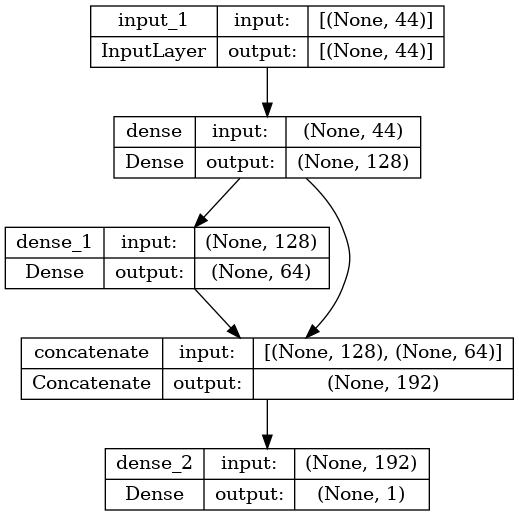

In [25]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

## Model Compilation

In [27]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
              loss='mean_squared_error', 
              metrics=['mean_squared_error', tf.keras.metrics.RootMeanSquaredError()])

## Model Training

In [28]:
history = model.fit(train_ds, validation_data=val_ds, epochs=100, verbose=1)

Epoch 1/100


2024-03-19 22:54:31.042481: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f652666f110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-19 22:54:31.042554: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2024-03-19 22:54:31.093494: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-03-19 22:54:31.188020: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1710863671.354170   99534 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 [==============================] - 4s 18ms/step - loss: 0.4775 - mean_squared_error: 0.4775 - root_mean_squared_error: 0.6910 - val_loss: 0.3023 - val_mean_squared_error: 0.3023 - val_root_mean_squared_error: 0.5498
Epoch 2/100
28/28 [==============================] - 0s 12ms/step - loss: 0.2078 - mean_squared_error: 0.2078 - root_mean_squared_error: 0.4559 - val_loss: 0.2388 - val_mean_squared_error: 0.2388 - val_root_mean_squared_error: 0.4886
Epoch 3/100
28/28 [==============================] - 0s 11ms/step - loss: 0.1638 - mean_squared_error: 0.1638 - root_mean_squared_error: 0.4047 - val_loss: 0.2066 - val_mean_squared_error: 0.2066 - val_root_mean_squared_error: 0.4546
Epoch 4/100
28/28 [==============================] - 0s 10ms/step - loss: 0.1463 - mean_squared_error: 0.1463 - root_mean_squared_error: 0.3825 - val_loss: 0.2000 - val_mean_squared_error: 0.2000 - val_root_mean_squared_error: 0.4472
Epoch 5/100
28/28 [==============================] - 0s 9ms/step - loss: 0.1

## Plot History

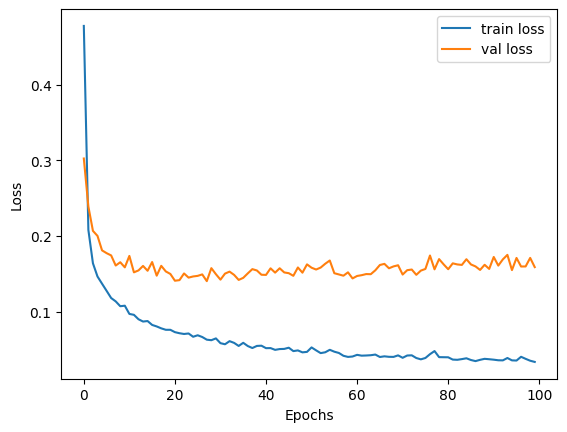

In [29]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(train_loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Model Testing

In [30]:
model.evaluate(test_ds)

6/6 [==============================] - 0s 10ms/step - loss: 0.1510 - mean_squared_error: 0.1510 - root_mean_squared_error: 0.3886


[0.15097370743751526, 0.15097370743751526, 0.38855335116386414]

In [31]:
model.save_weights('model_weights.h5')

In [32]:
y_pred_val = model.predict(x_val)
scaler_y.inverse_transform(y_pred_val)

6/6 [==============================] - 0s 5ms/step


array([[10.670522 ],
       [11.275681 ],
       [11.685255 ],
       [12.035552 ],
       [11.522495 ],
       [10.782289 ],
       [10.193735 ],
       [11.074895 ],
       [10.306022 ],
       [11.117816 ],
       [11.13241  ],
       [11.134851 ],
       [11.0634   ],
       [10.736037 ],
       [11.208531 ],
       [11.487442 ],
       [10.995442 ],
       [11.23442  ],
       [11.861193 ],
       [11.773751 ],
       [11.267736 ],
       [10.017745 ],
       [11.910835 ],
       [10.884857 ],
       [11.387782 ],
       [10.71347  ],
       [ 9.74583  ],
       [10.888373 ],
       [10.568839 ],
       [11.392701 ],
       [10.942068 ],
       [11.672067 ],
       [11.512274 ],
       [10.164988 ],
       [11.2516985],
       [11.163568 ],
       [11.414397 ],
       [11.477988 ],
       [10.85123  ],
       [10.136144 ],
       [10.261525 ],
       [11.438222 ],
       [ 9.437199 ],
       [ 9.458996 ],
       [ 9.960842 ],
       [10.5407095],
       [10.765349 ],
       [11.50

# Hyperparameter Tuning

## Define the Model and the Hyperparameter to be tuned

In [28]:
def model_builder(hp) :
    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    
    inputs = tf.keras.Input(shape=(x_train.shape[1],))
    dense_1 = Dense(units=hp_units, activation='relu')(inputs)
    dense_2 = Dense(units=hp_units, activation=tf.keras.layers.LeakyReLU(alpha=0.2), kernel_initializer=tf.keras.initializers.GlorotUniform())(dense_1)
    cat_layer = tf.keras.layers.Concatenate()([dense_1, dense_2])
    out = Dense(1, activation='linear')(cat_layer)
    
    model = Model(inputs=inputs, outputs=out)
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
              loss='mean_squared_error', 
              metrics=['mean_squared_error', tf.keras.metrics.RootMeanSquaredError()])
    
    return model

## Optimal Hyperparameter Search

In [29]:
tuner = kt.Hyperband(model_builder,
                     objective='val_loss',
                     max_epochs=20,
                     factor=3,
                     directory='exp',
                     project_name='kt')

In [31]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
tuner.search(x_train, y_train, validation_split=0.2, epochs=50, callbacks=[stop_early])

# Get optimal hyperparameter
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Trial 26 Complete [00h 00m 07s]
val_loss: 0.14395765960216522

Best val_loss So Far: 0.1209946721792221
Total elapsed time: 00h 02m 18s


In [38]:
best_hps.values

{'units': 256,
 'learning_rate': 0.01,
 'tuner/epochs': 20,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0}